In [ ]:
!git clone https://github.com/soancd-3648/driffmm.git
%cd driffmm

/Users/cao.duc.soan/Documents/soancd/DiffMM/driffmm


/Users/cao.duc.soan/Documents/soancd/DiffMM/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Tải dữ liệu và cài đặt môi trường

Tải dataset TikTok, cài đặt dependencies và nhập các module từ dự án.

In [ ]:
!pip install -q torch numpy scipy setproctitle tqdm gdown
!git pull origin main

import json
import os
import sys
from pathlib import Path

sys.argv = ["notebook"]

import torch
if not torch.cuda.is_available():
    torch.Tensor.cuda = lambda self, device=None, non_blocking=False: self
    torch.nn.Module.cuda = lambda self, device=None: self

from Params import args
from DataHandler import DataHandler
from Main import Coach, seed_it
from Model import GaussianDiffusion, Denoise, Model

print("✓ Dependencies installed and modules imported!")

import torch
import Utils.TimeLogger as logger
from Utils.TimeLogger import log
from Params import args
from Model import Model, GaussianDiffusion, Denoise
from DataHandler import DataHandler
import numpy as np
from Utils.Utils import *
import os
import scipy.sparse as sp
import random
import setproctitle
from scipy.sparse import coo_matrix

class Coach:
	def __init__(self, handler):
		self.handler = handler

		print('USER', args.user, 'ITEM', args.item)
		print('NUM OF INTERACTIONS', self.handler.trnLoader.dataset.__len__())
		self.metrics = dict()
		mets = ['Loss', 'preLoss', 'Recall', 'NDCG']
		for met in mets:
			self.metrics['Train' + met] = list()
			self.metrics['Test' + met] = list()

	def makePrint(self, name, ep, reses, save):
		ret = 'Epoch %d/%d, %s: ' % (ep, args.epoch, name)
		for metric in reses:
			val = reses[metric]
			ret += '%s = %.4f, ' % (metric, val)
			tem = name + metric
			if save and tem in self.metrics:
				self.metrics[tem].append(val)
		ret = ret[:-2] + ' 

In [ ]:
config = {
    "data": "tiktok",
    "epoch": 2,
    "batch": 4096,
    "tstBat": 512,
    "reg": 1e-4,
    "ssl_reg": 1e-2,
    "trans": 1,
    "e_loss": 0.1,
    "cl_method": 1,
    "conditional_diffusion": True,
    "cond_dim": 64,
    "cond_dropout": 0.1,
    "seed": 421,
}

for key, value in config.items():
    setattr(args, key, value)

seed_it(args.seed)
print("✓ Configuration loaded")
print(f"  Dataset: {args.data}")
print(f"  Conditional Diffusion: {'Enabled' if args.conditional_diffusion else 'Disabled'}")
print(f"  Epochs: {args.epoch}")

handler = DataHandler()
handler.LoadData()

coach = Coach(handler)
coach.run()

touch: cannot touch 'Utils/__init__.py': No such file or directory
Traceback (most recent call last):
  File "/content/Main.py", line 4, in <module>
    import Utils.TimeLogger as logger
ModuleNotFoundError: No module named 'Utils'


## Kết quả Training

Visualize metrics từ quá trình training Conditional Diffusion Model.

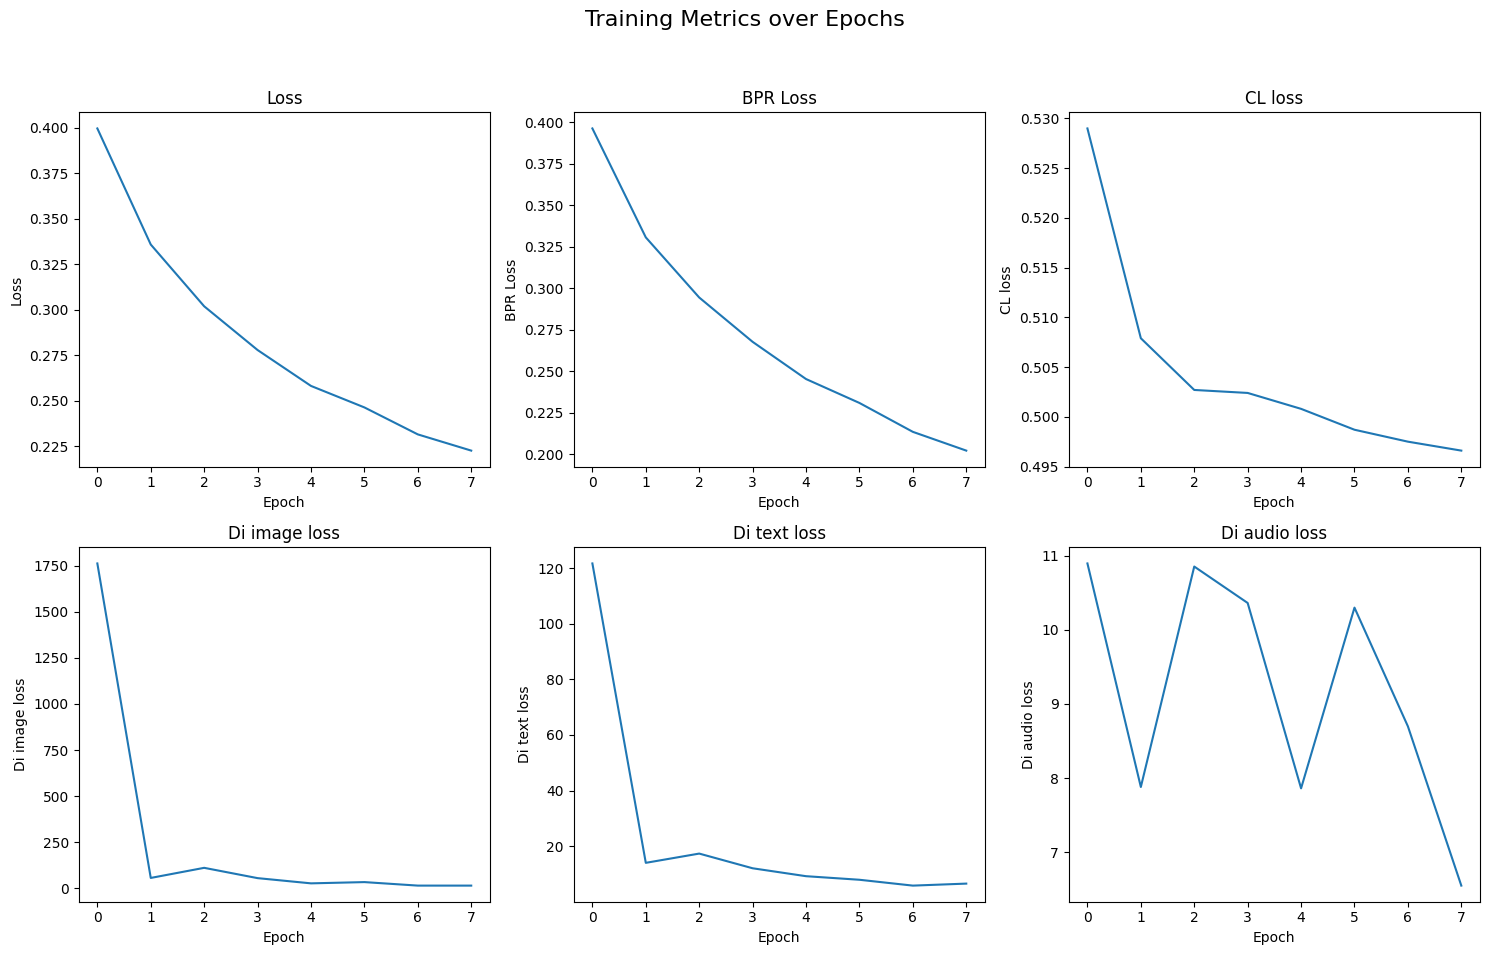

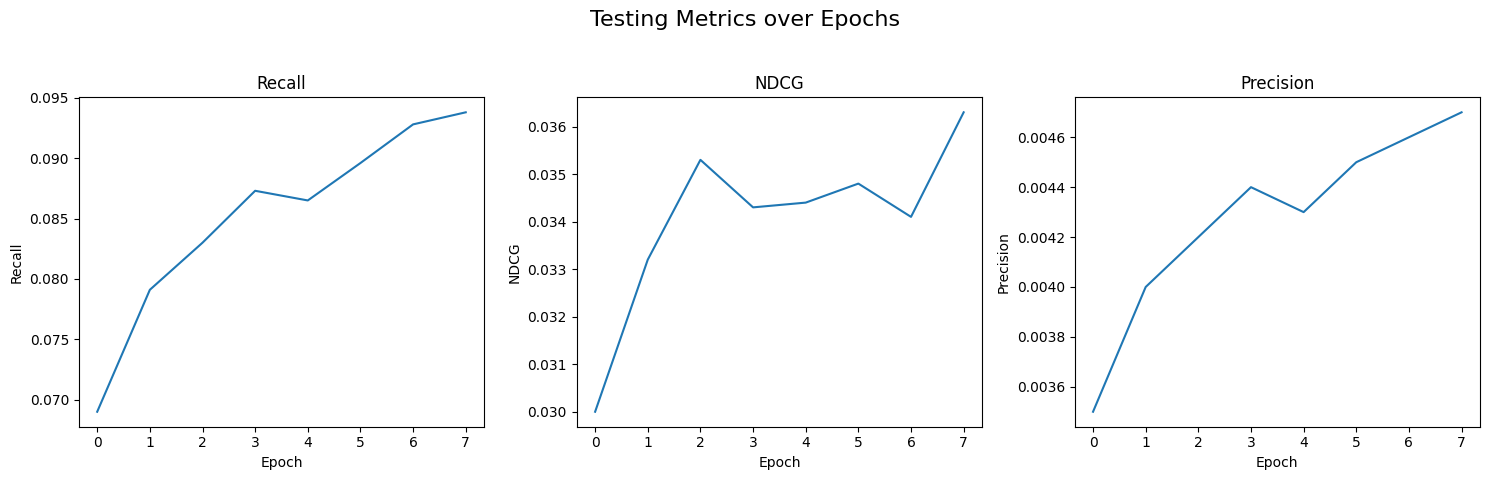

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Extract metrics from coach.metrics after training
train_data = {}
test_data = {}

for key, values in coach.metrics.items():
    if key.startswith('Train'):
        metric_name = key[5:]  # Remove 'Train' prefix
        train_data[metric_name] = values
    elif key.startswith('Test'):
        metric_name = key[4:]  # Remove 'Test' prefix
        test_data[metric_name] = values

# Create DataFrames
train_df = pd.DataFrame(train_data)
train_df['Epoch'] = range(len(train_df))

test_df = pd.DataFrame(test_data)
test_df['Epoch'] = range(len(test_df))

print("Training Metrics:")
print(train_df)
print("\nTesting Metrics:")
print(test_df)

# Plot Training Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Conditional Diffusion Training Metrics', fontsize=16, fontweight='bold')

if 'Loss' in train_df.columns:
    axes[0, 0].plot(train_df['Epoch'], train_df['Loss'], marker='o', linewidth=2)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].grid(True, alpha=0.3)

if 'BPR Loss' in train_df.columns:
    axes[0, 1].plot(train_df['Epoch'], train_df['BPR Loss'], marker='s', linewidth=2, color='orange')
    axes[0, 1].set_title('BPR Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].grid(True, alpha=0.3)

if 'CL loss' in train_df.columns:
    axes[1, 0].plot(train_df['Epoch'], train_df['CL loss'], marker='^', linewidth=2, color='green')
    axes[1, 0].set_title('Contrastive Learning Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].grid(True, alpha=0.3)

if 'preLoss' in train_df.columns:
    axes[1, 1].plot(train_df['Epoch'], train_df['preLoss'], marker='d', linewidth=2, color='red')
    axes[1, 1].set_title('Pre-training Loss')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot Test Metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Conditional Diffusion Test Metrics', fontsize=16, fontweight='bold')

if 'Recall' in test_df.columns:
    axes[0].plot(test_df['Epoch'], test_df['Recall'], marker='o', linewidth=2, color='blue')
    axes[0].set_title('Recall@20')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Recall')
    axes[0].grid(True, alpha=0.3)

if 'NDCG' in test_df.columns:
    axes[1].plot(test_df['Epoch'], test_df['NDCG'], marker='s', linewidth=2, color='green')
    axes[1].set_title('NDCG@20')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('NDCG')
    axes[1].grid(True, alpha=0.3)

if 'Precision' in test_df.columns:
    axes[2].plot(test_df['Epoch'], test_df['Precision'], marker='^', linewidth=2, color='red')
    axes[2].set_title('Precision@20')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Precision')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")